In [1]:
%%time  

# pip3 install torch torchvision
# pip install tqdm
# pip install scikit-learn seaborn matplotlib
# pip install --upgrade  notebook jupyter nbconvert

import time
from pathlib import Path

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.metrics import classification_report

# Vérifie si PyTorch est bien installé
print(f"Version de PyTorch : {torch.__version__}")

Version de PyTorch : 2.11.0+cpu
CPU times: total: 4.72 s
Wall time: 5.08 s


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Transfer Learning

</div>

In [2]:
%%time 

# Les transformations doivent être identiques pour le train et la val
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

CPU times: total: 0 ns
Wall time: 1.01 ms


In [3]:
%%time 

# Chargement des datasets

base_dir = "C:/Users/huber_otpq54a/OneDrive/Documents/Formation/IA/Developpement/Projets/Deep_Learning_V3/data3a"
train_dataset = datasets.ImageFolder(base_dir + '/training', transform=data_transforms)
val_dataset = datasets.ImageFolder(base_dir + '/validation', transform=data_transforms)

# Création des loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Classes détectées : {train_dataset.classes}")

Classes détectées : ['00-normal', '01-minor', '02-moderate', '03-severe']
CPU times: total: 31.2 ms
Wall time: 30.8 ms


In [4]:
%%time 

class DinoClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(DinoClassifier, self).__init__()
        # Chargement du backbone DINOv2 (Small) via Torch Hub
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        
        # On gèle les paramètres pour ne faire que du "Linear Probing"
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Couche de classification : DINOv2 ViT-S a 384 sorties
        self.classifier = nn.Linear(384, num_classes)

    def forward(self, x):
        # Utiliser no_grad ici pour économiser de la mémoire sur le backbone
        with torch.no_grad():
            features = self.backbone(x)
        return self.classifier(features)

print("Modèle chargé et prêt !")

Modèle chargé et prêt !
CPU times: total: 0 ns
Wall time: 0 ns


In [5]:
%%time 

device = "cpu"

# Initialisation du modèle (voir code précédent pour la classe DinoClassifier)
model = DinoClassifier(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# --- Boucle d'entraînement simplifiée ---
epochs = 10

for epoch in range(epochs):
    # Phase d'entraînement
    model.train()

    # On enveloppe le loader avec tqdm
    train_bar = tqdm(train_loader, desc=f"Époque {epoch+1}/{epochs}")
    
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Affiche la perte en direct à côté de la barre
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Phase de validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Époque {epoch+1}/{epochs} - Loss: {train_loss/len(train_loader):.4f} - Précision Val: {100 * correct / total:.2f}%")

Using cache found in C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Époque 1/10:   0%|          | 0/58 [01:20<?, ?it/s, loss=0.7517]

Époque 1/10 - Loss: 0.8992 - Précision Val: 76.64%


Époque 1/10:   0%|          | 0/58 [01:39<?, ?it/s, loss=0.7517]


Époque 2/10 - Loss: 0.6140 - Précision Val: 82.73%


Époque 3/10:   0%|          | 0/58 [01:07<?, ?it/s, loss=0.3420]

...

Époque 8/10 - Loss: 0.4283 - Précision Val: 83.45%


Époque 9/10:   0%|          | 0/58 [01:07<?, ?it/s, loss=0.3850]

Époque 9/10 - Loss: 0.4116 - Précision Val: 79.32%


Époque 9/10:   0%|          | 0/58 [01:22<?, ?it/s, loss=0.3850]


Époque 10/10 - Loss: 0.4042 - Précision Val: 81.27%
CPU times: total: 1h 50min 19s
Wall time: 13min 57s


In [6]:
%%time 

def plot_confusion_matrix(model, loader, classes):
    all_preds = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calcul de la matrice
    cm = confusion_matrix(all_labels, all_preds)
    
    # Affichage avec Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies Valeurs')
    plt.title('Matrice de Confusion')
    
    print(classification_report(all_labels, all_preds, target_names=classes))
    plt.show()

def plot_confusion_matrix_percentage(model, loader, classes):
    all_preds = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Normalisation : 'true' normalise sur les lignes (vraies étiquettes)
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    
    plt.figure(figsize=(10, 8))
    # fmt='.2%' affiche les nombres sous forme 95.50%
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Greens', 
                xticklabels=classes, yticklabels=classes)
    
    plt.xlabel('Prédictions (Labels Prédits)')
    plt.ylabel('Réalité (Vrais Labels)')
    plt.title('Matrice de Confusion en Pourcentage')
    plt.show()



CPU times: total: 0 ns
Wall time: 0 ns


              precision    recall  f1-score   support

   00-normal       0.99      0.96      0.98       163
    01-minor       0.83      0.77      0.80        82
 02-moderate       0.53      0.53      0.53        75
   03-severe       0.73      0.81      0.77        91

    accuracy                           0.81       411
   macro avg       0.77      0.77      0.77       411
weighted avg       0.82      0.81      0.81       411



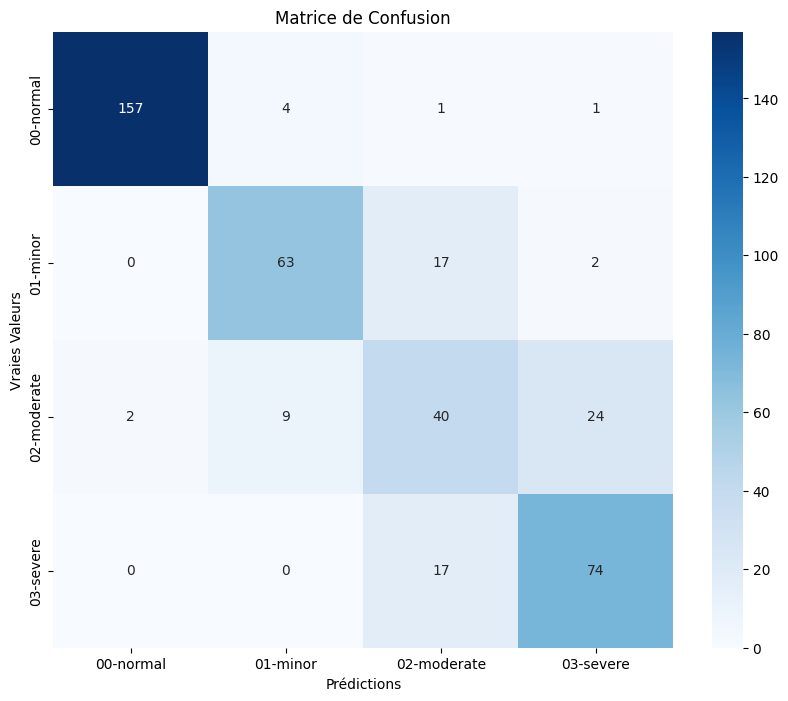

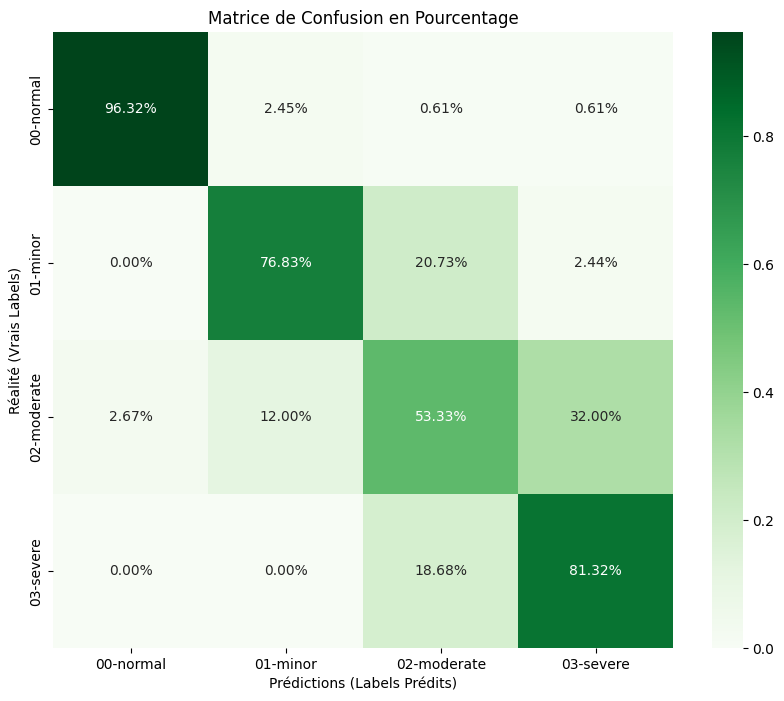

CPU times: total: 3min 54s
Wall time: 29.4 s


In [7]:
%%time 

# Utilisation :
plot_confusion_matrix(model, val_loader, train_dataset.classes)

plot_confusion_matrix_percentage(model, val_loader, train_dataset.classes)

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Fine Tuning

</div>

In [8]:
%%time 

# 1. On autorise les gradients sur TOUT le modèle
for param in model.backbone.parameters():
    param.requires_grad = True

# 2. On définit des taux d'apprentissage différents (Differential Learning Rates)
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5}, # Très lent pour le corps
    {'params': model.classifier.parameters(), 'lr': 1e-4} # Un peu plus rapide pour la tête
], weight_decay=0.01)

# On utilise souvent un scheduler pour réduire le LR progressivement
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

CPU times: total: 0 ns
Wall time: 2.13 ms


In [9]:
%%time 

def validate_model(model, loader, criterion, device):
    model.eval()  # Mode évaluation (désactive dropout, batchnorm, etc.)
    running_loss = 0.0
    correct = 0
    total = 0
    
    # On désactive le calcul des gradients pour gagner du temps et de la mémoire
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            
            # Récupérer l'indice de la classe ayant la probabilité la plus élevée
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    avg_loss = running_loss / len(loader)
    
    return avg_loss, accuracy

CPU times: total: 0 ns
Wall time: 0 ns


In [10]:
%%time 

class EarlyStopping:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # On pourrait sauvegarder le modèle ici
        else:
            self.counter += 1
            print(f"EarlyStopping : {self.counter} / {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

CPU times: total: 0 ns
Wall time: 0 ns


In [ ]:
%%time 

epochs = 5
early_stopper = EarlyStopping(patience=1, min_delta=0.01)
best_accuracy = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for images, labels in tqdm(train_loader, desc=f"Fine-tuning Époque {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images) # Ici, le gradient passera dans tout le modèle
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Optionnel : Gradient Clipping pour éviter les explosions de gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
    
    scheduler.step()

    # --- PHASE DE VALIDATION ---
    val_loss, val_acc = validate_model(model, val_loader, criterion, device)
    
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.2f}%")
    print("-" * 30)
    
    # Sauvegarder le meilleur modèle
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), 'best_dino_finetuned.pth')

    # 3. Vérification de l'arrêt précoce
    early_stopper(val_loss)
    if early_stopper.early_stop:
        print("Arrêt précoce déclenché. Le modèle ne s'améliore plus.")
        break

    

    

Fine-tuning Époque 1: 100%|██████████| 58/58 [01:06<00:00,  1.15s/it]


Epoch [1/5]
Train Loss: 0.3698
Val Loss: 0.4243 | Val Accuracy: 81.51%
------------------------------


Fine-tuning Époque 2: 100%|██████████| 58/58 [01:07<00:00,  1.17s/it]


Epoch [2/5]
Train Loss: 0.3643
Val Loss: 0.4247 | Val Accuracy: 82.24%
------------------------------
EarlyStopping : 1 / 1
Arrêt précoce déclenché. Le modèle ne s'améliore plus.
CPU times: total: 21min 45s
Wall time: 2min 44s


              precision    recall  f1-score   support

   00-normal       0.99      0.95      0.97       163
    01-minor       0.78      0.82      0.80        82
 02-moderate       0.56      0.57      0.57        75
   03-severe       0.80      0.80      0.80        91

    accuracy                           0.82       411
   macro avg       0.78      0.79      0.78       411
weighted avg       0.83      0.82      0.82       411



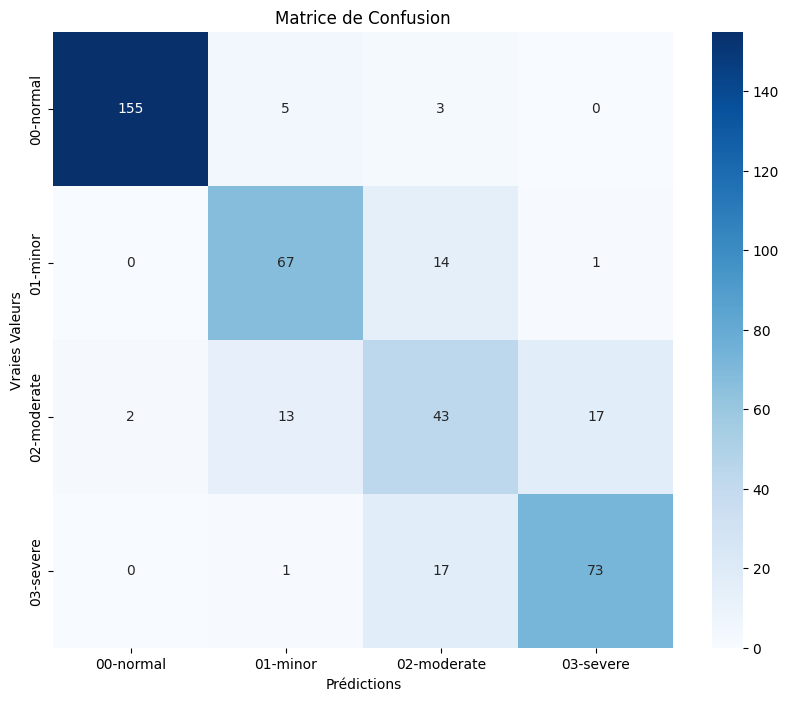

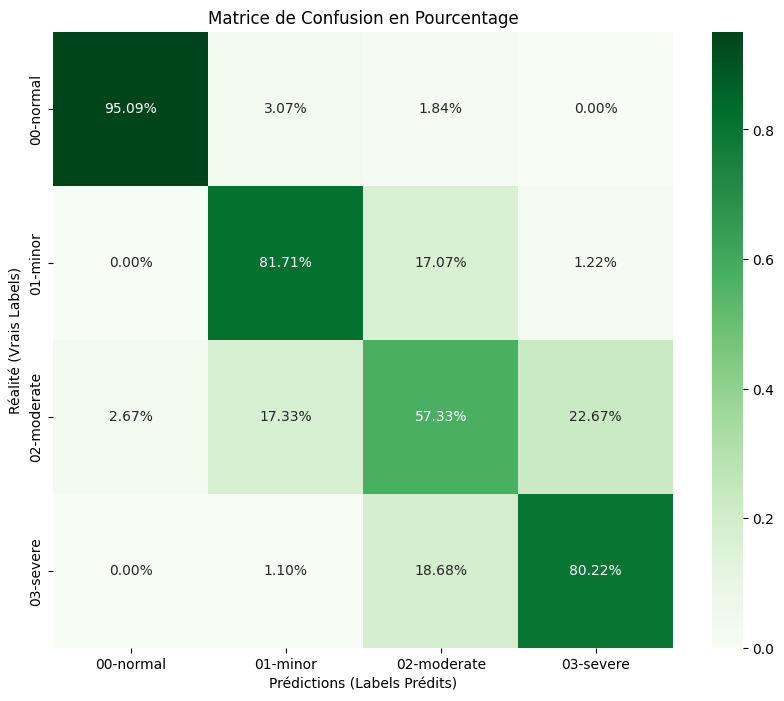

CPU times: total: 4min 1s
Wall time: 30.4 s


In [12]:
%%time 

# Utilisation :
plot_confusion_matrix(model, val_loader, train_dataset.classes)

plot_confusion_matrix_percentage(model, val_loader, train_dataset.classes)

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Test

</div>

In [13]:
%%time 

project_root = Path.cwd()
print("project_root : " + str(project_root))

# 1. Recréer l'architecture
model_test = DinoClassifier(num_classes=4)

# 2. Charger les poids (le dictionnaire d'états)
model_test.load_state_dict(torch.load(str(project_root) + '/best_dino_finetuned.pth'))
model_test.to(device)
model_test.eval()

print("Modèle rechargé et prêt pour l'inférence !")

project_root : c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\DINOv2


Using cache found in C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main


Modèle rechargé et prêt pour l'inférence !
CPU times: total: 2.94 s
Wall time: 1.23 s
